In [1]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

X1 = np.array([
    [1,1], [3,2], [9,1],
    [3,7], [7,2], [9,7],
    [4,8], [8,3], [1,4]
])

In [3]:
X1

array([[1, 1],
       [3, 2],
       [9, 1],
       [3, 7],
       [7, 2],
       [9, 7],
       [4, 8],
       [8, 3],
       [1, 4]])

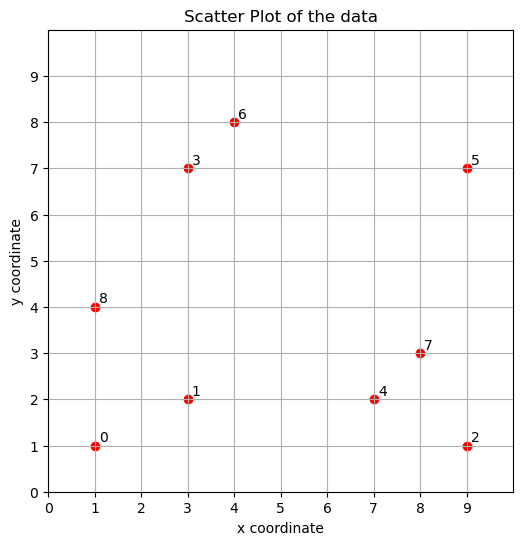

In [6]:

plt.figure(figsize=(6, 6))

plt.scatter(X1[:,0], X1[:,1], c='r')

# Create numbered labels for each point
for i in range(X1.shape[0]):
    plt.annotate(str(i), xy=(X1[i,0], X1[i,1]), xytext=(3, 3), textcoords='offset points')

    
plt.xlabel('x coordinate')
plt.ylabel('y coordinate')
plt.title('Scatter Plot of the data')
plt.xlim([0,10]), plt.ylim([0,10])
plt.xticks(range(10)), plt.yticks(range(10))
plt.grid()

plt.show()

### Using scipy library

In [7]:

from scipy.cluster.hierarchy import dendrogram, linkage

Z1 = linkage(X1, method='single', metric='euclidean')
Z2 = linkage(X1, method='complete', metric='euclidean')
Z3 = linkage(X1, method='average', metric='euclidean')


In [8]:
linkage(X1, method='ward')

array([[ 4.        ,  7.        ,  1.41421356,  2.        ],
       [ 3.        ,  6.        ,  1.41421356,  2.        ],
       [ 0.        ,  1.        ,  2.23606798,  2.        ],
       [ 2.        ,  9.        ,  2.44948974,  3.        ],
       [ 8.        , 11.        ,  3.10912635,  3.        ],
       [ 5.        , 12.        ,  6.244998  ,  4.        ],
       [10.        , 13.        ,  8.49313448,  5.        ],
       [14.        , 15.        , 12.56892111,  9.        ]])

In [ ]:

### syntax of above four lines

[cluster1, cluster2, distance, sample_count]

Step by step:

[4, 7, 1.4142, 2]

    Merge point 4 and point 7 (distance ≈ 1.41).
    
    New cluster has 2 samples.

[3, 6, 1.4142, 2]

    Merge point 3 and point 6 (distance ≈ 1.41).
    
    New cluster has 2 samples.

....

[10, 13, 8.4931, 5]

    Merge cluster 10 (from step 2) with cluster 13.
    
    Distance ≈ 8.49, cluster size = 5.

[14, 15, 12.5689, 9]

    Merge cluster 14 (step 6) with cluster 15 (step 7).
    
    Distance ≈ 12.57, cluster size = 9.

 This is the final merge (all 9 points grouped together).
 

In [10]:

#Z4 = linkage(X1, method='ward', metric='euclidean')

Z4 = linkage(X1, method='ward')



 method='ward' is based on minimizing variance within clusters.
    
    By definition, Ward’s method requires squared Euclidean distance.
    
    Because of this, SciPy forces Euclidean internally.
    

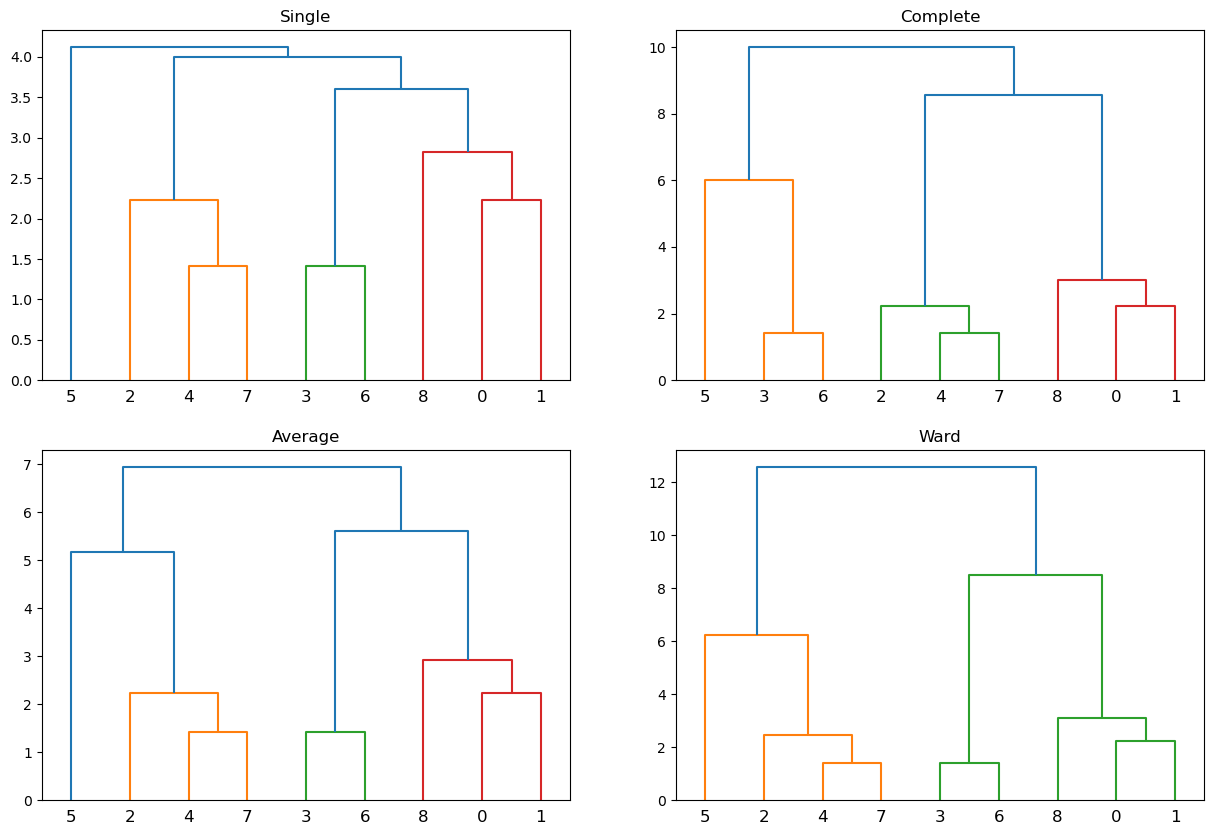

In [11]:

plt.figure(figsize=(15, 10))

plt.subplot(2,2,1), dendrogram(Z1), plt.title('Single')
plt.subplot(2,2,2), dendrogram(Z2), plt.title('Complete')
plt.subplot(2,2,3), dendrogram(Z3), plt.title('Average')
plt.subplot(2,2,4), dendrogram(Z4), plt.title('Ward')

plt.show()

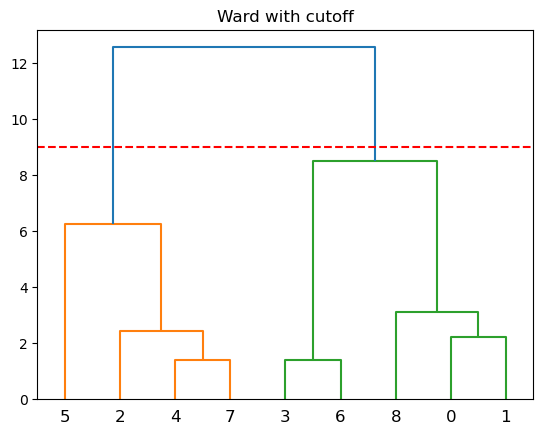

In [12]:

dendrogram(Z4)

plt.axhline(y=9, c='red', linestyle='--')  # adjust y based on dendrogram
plt.title('Ward with cutoff')
plt.show()


In [13]:

from scipy.cluster.hierarchy import fcluster

f1 = fcluster(Z4, 2, criterion='maxclust')

print(f"Clusters: {f1}")


Clusters: [2 2 1 2 1 1 2 1 2]


### sklearn AgglomerativeClustering

In [14]:
from sklearn.cluster import AgglomerativeClustering

Z1 = AgglomerativeClustering(n_clusters=2, linkage='ward')

Z1.fit_predict(X1)

print(Z1.labels_)


[0 0 1 0 1 1 0 1 0]


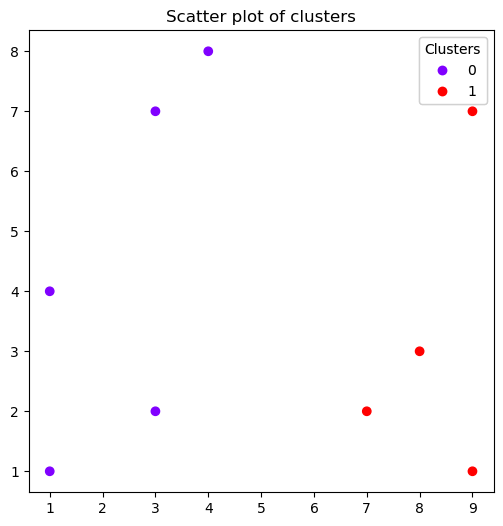

In [15]:

fig, ax = plt.subplots(figsize=(6, 6))

scatter = ax.scatter(X1[:,0], X1[:,1], c=Z1.labels_, cmap='rainbow')

legend = ax.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1, 1))
ax.add_artist(legend)

plt.title('Scatter plot of clusters')

plt.show()


In [16]:

print("fcluster (SciPy):", f1)
print("Agglomerative (sklearn):", Z1.labels_)


fcluster (SciPy): [2 2 1 2 1 1 2 1 2]
Agglomerative (sklearn): [0 0 1 0 1 1 0 1 0]
